Using device: cpu

MEMORY-EFFICIENT LSTM WITH ATTENTION

PROCESSING ASPECT RATIO 0.3
Loading 0.3.xlsx...
  Subsampling from 25000 to 15000 rows (RAM safety)
Creating sequences (memory-efficient)...
  Created 14990 sequences
Splitting data...
Normalizing...
✓ Train: (11992, 10, 4), Test: (2998, 10, 4)
  Memory usage: ~2.4 MB

Training AR 0.3
Training...
Epoch   1/100 | Train: 0.221459 | Val: 0.018877 | Best: 0.018877 | LR: 0.001000
Epoch  10/100 | Train: 0.016603 | Val: 0.004674 | Best: 0.000601 | LR: 0.001000
Epoch  20/100 | Train: 0.016932 | Val: 0.001534 | Best: 0.000206 | LR: 0.000500
Epoch  30/100 | Train: 0.015618 | Val: 0.000232 | Best: 0.000206 | LR: 0.000250
Early stopping at epoch 32
✓ Restored best model (val loss: 0.000206)
Evaluating...

────────────────────────────────────────────────────────────
RESULTS FOR AR 0.3:
  MAE:       0.1155 K
  RMSE:      0.1371 K
  R²:        0.9998
  MAE (>70°C): 0.1148 K (2458 samples)
  Temp range: 301.88 - 353.01 K
────────────────────────

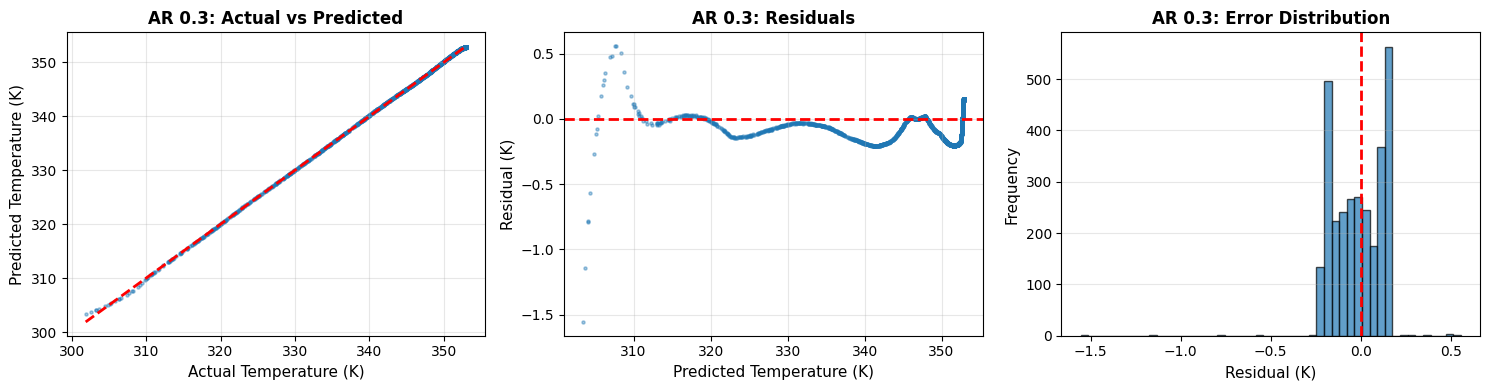


PROCESSING ASPECT RATIO 0.4
Loading 0.4.xlsx...
  Subsampling from 27497 to 15000 rows (RAM safety)
Creating sequences (memory-efficient)...
  Created 14990 sequences
Splitting data...
Normalizing...
✓ Train: (11992, 10, 4), Test: (2998, 10, 4)
  Memory usage: ~2.4 MB

Training AR 0.4
Training...
Epoch   1/100 | Train: 0.258535 | Val: 0.015767 | Best: 0.015767 | LR: 0.001000
Epoch  10/100 | Train: 0.018613 | Val: 0.000825 | Best: 0.000382 | LR: 0.001000
Epoch  20/100 | Train: 0.017849 | Val: 0.001272 | Best: 0.000227 | LR: 0.001000
Epoch  30/100 | Train: 0.017657 | Val: 0.001418 | Best: 0.000211 | LR: 0.000500
Epoch  40/100 | Train: 0.018066 | Val: 0.002510 | Best: 0.000118 | LR: 0.000500
Epoch  50/100 | Train: 0.018202 | Val: 0.000364 | Best: 0.000083 | LR: 0.000250
Epoch  60/100 | Train: 0.017507 | Val: 0.000126 | Best: 0.000083 | LR: 0.000125
Early stopping at epoch 64
✓ Restored best model (val loss: 0.000083)
Evaluating...

────────────────────────────────────────────────────────

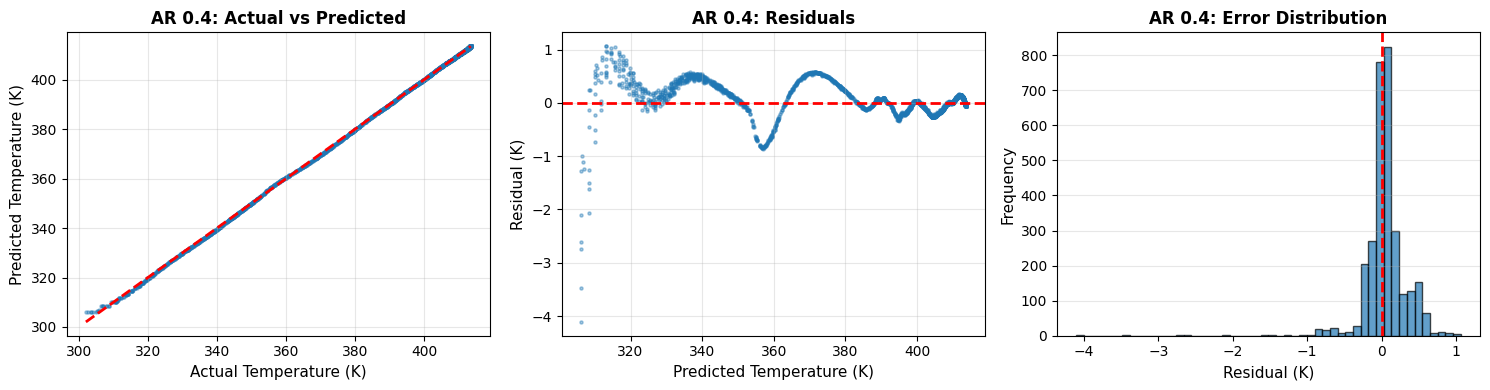


PROCESSING ASPECT RATIO 0.5
Loading 0.5.xlsx...
  Subsampling from 25000 to 15000 rows (RAM safety)
Creating sequences (memory-efficient)...
  Created 14990 sequences
Splitting data...
Normalizing...
✓ Train: (11992, 10, 4), Test: (2998, 10, 4)
  Memory usage: ~2.4 MB

Training AR 0.5
Training...
Epoch   1/100 | Train: 0.243281 | Val: 0.005812 | Best: 0.005812 | LR: 0.001000
Epoch  10/100 | Train: 0.017071 | Val: 0.006877 | Best: 0.001281 | LR: 0.001000
Epoch  20/100 | Train: 0.016127 | Val: 0.005510 | Best: 0.000755 | LR: 0.001000
Epoch  30/100 | Train: 0.016729 | Val: 0.001539 | Best: 0.000593 | LR: 0.000500
Epoch  40/100 | Train: 0.017165 | Val: 0.001441 | Best: 0.000573 | LR: 0.000500
Epoch  50/100 | Train: 0.015581 | Val: 0.002046 | Best: 0.000530 | LR: 0.000250
Epoch  60/100 | Train: 0.016120 | Val: 0.000582 | Best: 0.000502 | LR: 0.000125
Epoch  70/100 | Train: 0.016072 | Val: 0.001137 | Best: 0.000454 | LR: 0.000125
Epoch  80/100 | Train: 0.016300 | Val: 0.000403 | Best: 0.000

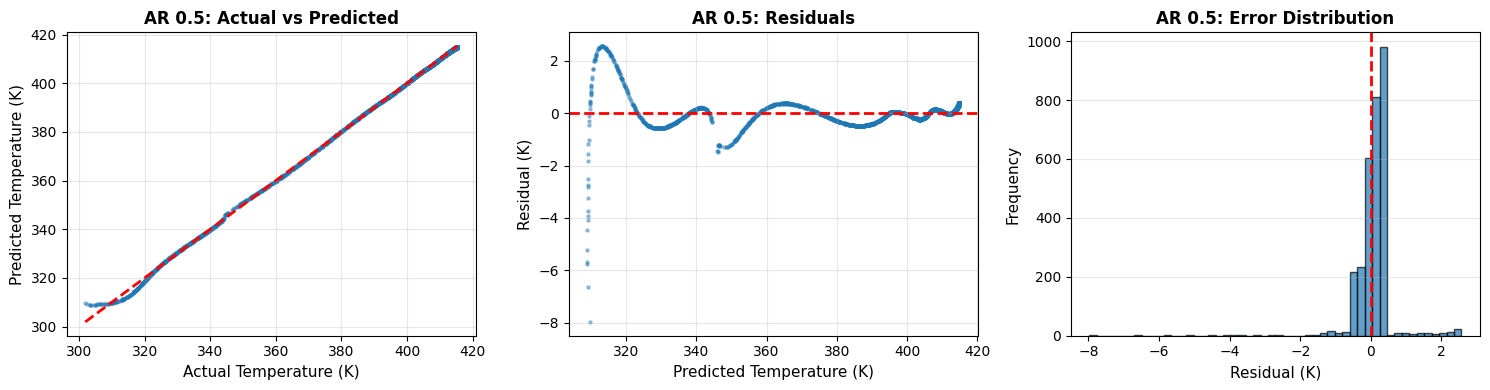


FINAL SUMMARY

 aspect_ratio      mae     rmse       r2  mae_high_temp  high_temp_samples   temp_min   temp_max  samples
          0.3 0.115530 0.137089 0.999789       0.114761               2458 301.880829 353.011414     2998
          0.4 0.175536 0.285350 0.999910       0.137224               2622 302.031311 413.517242     2998
          0.5 0.300094 0.540475 0.999665       0.227305               2654 301.881439 415.300537     2998

✓ Results saved to 'memory_efficient_lstm_results.csv'
COMPLETED!


In [1]:
# ============================================================================
# MEMORY-EFFICIENT LSTM FOR BATTERY THERMAL MANAGEMENT
# RAM-saving improvements:
# 1. Process data in chunks (don't load everything at once)
# 2. Delete intermediate variables
# 3. Use float32 instead of float64
# 4. Gradient checkpointing
# 5. No augmentation (memory hog)
# 6. Subsample data if too large
# ============================================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
import gc
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============================================================================
# MEMORY-EFFICIENT DATA LOADING
# ============================================================================

def load_and_preprocess_data(data_path, test_ratio=0.2, seq_length=10, max_samples=15000):
    """
    Load data efficiently - subsample if too large to prevent RAM overflow.
    """
    print(f"Loading {data_path}...")

    # Read only necessary columns
    data = pd.read_excel(data_path, usecols=['time', 'aspect_ratio', 'liquid_frac', 'Nu', 'T_pcm', 'T_battery'])
    data = data.sort_values('time').reset_index(drop=True)

    # SUBSAMPLE if data is too large (prevents RAM overflow)
    if len(data) > max_samples:
        print(f"  Subsampling from {len(data)} to {max_samples} rows (RAM safety)")
        # Use stratified sampling to keep diversity
        indices = np.linspace(0, len(data)-1, max_samples, dtype=int)
        data = data.iloc[indices].reset_index(drop=True)

    features = ['aspect_ratio', 'liquid_frac', 'Nu', 'T_pcm']
    target_col = 'T_battery'

    # Create sequences IN CHUNKS to save memory
    print("Creating sequences (memory-efficient)...")
    chunk_size = 5000
    X_chunks = []
    y_chunks = []

    for start_idx in range(0, len(data) - seq_length, chunk_size):
        end_idx = min(start_idx + chunk_size, len(data) - seq_length)

        X_chunk = []
        y_chunk = []

        for i in range(start_idx, end_idx):
            X_chunk.append(data[features].iloc[i:i+seq_length].values.astype(np.float32))
            y_chunk.append(data[target_col].iloc[i+seq_length])

        X_chunks.append(np.array(X_chunk, dtype=np.float32))
        y_chunks.append(np.array(y_chunk, dtype=np.float32))

        # Clear memory
        del X_chunk, y_chunk
        gc.collect()

    # Combine chunks
    X = np.vstack(X_chunks)
    y = np.hstack(y_chunks)

    del X_chunks, y_chunks, data
    gc.collect()

    print(f"  Created {len(X)} sequences")

    # Random split
    print("Splitting data...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_ratio, random_state=42, shuffle=True
    )

    del X, y
    gc.collect()

    # Normalize (use float32)
    print("Normalizing...")
    X_mean = X_train.mean(axis=(0, 1)).astype(np.float32)
    X_std = X_train.std(axis=(0, 1)).astype(np.float32)
    y_mean = float(y_train.mean())
    y_std = float(y_train.std())

    X_train = ((X_train - X_mean) / (X_std + 1e-8)).astype(np.float32)
    X_test = ((X_test - X_mean) / (X_std + 1e-8)).astype(np.float32)
    y_train = ((y_train - y_mean) / (y_std + 1e-8)).astype(np.float32)
    y_test = ((y_test - y_mean) / (y_std + 1e-8)).astype(np.float32)

    norm_stats = (X_mean, X_std, y_mean, y_std)

    print(f"✓ Train: {X_train.shape}, Test: {X_test.shape}")
    print(f"  Memory usage: ~{(X_train.nbytes + X_test.nbytes) / 1e6:.1f} MB")

    return X_train, X_test, y_train, y_test, norm_stats


# ============================================================================
# IMPROVED LSTM MODEL (Better than "too simple" but memory-efficient)
# ============================================================================

class MemoryEfficientLSTM(nn.Module):
    def __init__(self, input_size=4, hidden_size=64):
        super().__init__()

        # 2-layer LSTM (good balance)
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )

        # Attention mechanism (improves performance without much memory)
        self.attention = nn.Linear(hidden_size, 1)

        # Prediction head
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # LSTM
        lstm_out, _ = self.lstm(x)  # (batch, seq, hidden)

        # Attention weights
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)  # (batch, seq, 1)

        # Weighted sum
        context = torch.sum(attn_weights * lstm_out, dim=1)  # (batch, hidden)

        # Predict
        return self.fc(context)


# ============================================================================
# MEMORY-EFFICIENT TRAINING
# ============================================================================

def train_model(X_train, y_train, X_test, y_test, norm_stats, aspect_ratio):
    print(f"\n{'='*60}")
    print(f"Training AR {aspect_ratio}")
    print(f"{'='*60}")

    # Subsample training data if still too large
    if len(X_train) > 20000:
        print(f"  Subsampling training set from {len(X_train)} to 20000")
        indices = np.random.choice(len(X_train), 20000, replace=False)
        X_train = X_train[indices]
        y_train = y_train[indices]
        gc.collect()

    # Convert to tensors (don't move to GPU yet to save VRAM)
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

    del X_train, y_train, X_test, y_test
    gc.collect()

    # DataLoader with pin_memory for faster GPU transfer
    train_ds = torch.utils.data.TensorDataset(X_train_t, y_train_t)
    train_loader = torch.utils.data.DataLoader(
        train_ds,
        batch_size=128,  # Moderate batch size
        shuffle=True,
        num_workers=0,
        pin_memory=True if device.type == 'cuda' else False
    )

    # Smaller validation set
    val_len = min(1000, len(X_test_t))
    X_val = X_test_t[:val_len]
    y_val = y_test_t[:val_len]

    # Model
    model = MemoryEfficientLSTM(input_size=4, hidden_size=64).to(device)

    # Loss and optimizer
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=8, factor=0.5
    )

    # Training
    max_epochs = 100
    patience = 15
    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    print("Training...")
    for epoch in range(max_epochs):
        model.train()
        train_loss = 0

        for batch_X, batch_y in train_loader:
            # Move to device only when needed
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            pred = model(batch_X)
            loss = criterion(pred, batch_y)
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            train_loss += loss.item()

            # Clear GPU cache
            if device.type == 'cuda':
                del batch_X, batch_y, pred, loss
                torch.cuda.empty_cache()

        train_loss /= len(train_loader)

        # Validation
        model.eval()
        with torch.no_grad():
            X_val_dev = X_val.to(device)
            y_val_dev = y_val.to(device)
            val_pred = model(X_val_dev)
            val_loss = criterion(val_pred, y_val_dev).item()

            if device.type == 'cuda':
                del X_val_dev, y_val_dev, val_pred
                torch.cuda.empty_cache()

        scheduler.step(val_loss)

        # Early stopping
        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        # Print progress
        if (epoch + 1) % 10 == 0 or epoch == 0:
            lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch+1:3d}/{max_epochs} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | Best: {best_val_loss:.6f} | LR: {lr:.6f}")

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    # Restore best model
    if best_state:
        model.load_state_dict(best_state)
        print(f"✓ Restored best model (val loss: {best_val_loss:.6f})")

    del best_state
    gc.collect()

    return model, X_test_t, y_test_t


# ============================================================================
# EVALUATION
# ============================================================================

def evaluate_model(model, X_test_t, y_test_t, norm_stats, aspect_ratio):
    print("Evaluating...")

    model.eval()

    # Process in batches to avoid memory issues
    batch_size = 1000
    predictions = []

    with torch.no_grad():
        for i in range(0, len(X_test_t), batch_size):
            batch = X_test_t[i:i+batch_size].to(device)
            pred = model(batch).cpu().numpy()
            predictions.append(pred)

            del batch
            if device.type == 'cuda':
                torch.cuda.empty_cache()

    y_pred_norm = np.vstack(predictions).flatten()
    y_test_norm = y_test_t.cpu().numpy().flatten()

    # Denormalize
    y_mean, y_std = norm_stats[2], norm_stats[3]
    y_test_actual = y_test_norm * y_std + y_mean
    y_pred_actual = y_pred_norm * y_std + y_mean

    # Metrics
    mae = mean_absolute_error(y_test_actual, y_pred_actual)
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
    r2 = r2_score(y_test_actual, y_pred_actual)

    # High temp metrics
    mask_high = y_test_actual > 343.15  # 70°C in Kelvin
    if mask_high.sum() > 0:
        mae_high = mean_absolute_error(y_test_actual[mask_high], y_pred_actual[mask_high])
        high_samples = int(mask_high.sum())
    else:
        mae_high = 0.0
        high_samples = 0

    metrics = {
        'aspect_ratio': aspect_ratio,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'mae_high_temp': mae_high,
        'high_temp_samples': high_samples,
        'temp_min': float(y_test_actual.min()),
        'temp_max': float(y_test_actual.max()),
        'samples': len(y_test_actual)
    }

    return metrics, y_pred_actual, y_test_actual


# ============================================================================
# VISUALIZATION
# ============================================================================

def plot_predictions(y_test_actual, y_pred_actual, aspect_ratio):
    # Subsample for plotting if too many points
    if len(y_test_actual) > 5000:
        indices = np.random.choice(len(y_test_actual), 5000, replace=False)
        y_test_plot = y_test_actual[indices]
        y_pred_plot = y_pred_actual[indices]
    else:
        y_test_plot = y_test_actual
        y_pred_plot = y_pred_actual

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Scatter
    axes[0].scatter(y_test_plot, y_pred_plot, alpha=0.4, s=5)
    axes[0].plot([y_test_plot.min(), y_test_plot.max()],
                 [y_test_plot.min(), y_test_plot.max()], 'r--', lw=2)
    axes[0].set_xlabel('Actual Temperature (K)', fontsize=11)
    axes[0].set_ylabel('Predicted Temperature (K)', fontsize=11)
    axes[0].set_title(f'AR {aspect_ratio}: Actual vs Predicted', fontweight='bold')
    axes[0].grid(True, alpha=0.3)

    # Residuals
    residuals = y_test_actual - y_pred_actual
    axes[1].scatter(y_pred_actual, residuals, alpha=0.4, s=5)
    axes[1].axhline(0, color='r', linestyle='--', lw=2)
    axes[1].set_xlabel('Predicted Temperature (K)', fontsize=11)
    axes[1].set_ylabel('Residual (K)', fontsize=11)
    axes[1].set_title(f'AR {aspect_ratio}: Residuals', fontweight='bold')
    axes[1].grid(True, alpha=0.3)

    # Histogram
    axes[2].hist(residuals, bins=50, alpha=0.7, edgecolor='black')
    axes[2].axvline(0, color='r', linestyle='--', lw=2)
    axes[2].set_xlabel('Residual (K)', fontsize=11)
    axes[2].set_ylabel('Frequency', fontsize=11)
    axes[2].set_title(f'AR {aspect_ratio}: Error Distribution', fontweight='bold')
    axes[2].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()


# ============================================================================
# MAIN EXECUTION
# ============================================================================

aspect_configs = [
    {'ar': 0.3, 'path': '0.3.xlsx'},
    {'ar': 0.4, 'path': '0.4.xlsx'},
    {'ar': 0.5, 'path': '0.5.xlsx'},
]

all_metrics = []

print("\n" + "="*60)
print("MEMORY-EFFICIENT LSTM WITH ATTENTION")
print("="*60)

for cfg in aspect_configs:
    ar = cfg['ar']
    path = cfg['path']

    print(f"\n{'='*60}")
    print(f"PROCESSING ASPECT RATIO {ar}")
    print(f"{'='*60}")

    # Load data (with memory limits)
    X_train, X_test, y_train, y_test, norm_stats = load_and_preprocess_data(
        path, max_samples=15000
    )

    # Train
    model, X_test_t, y_test_t = train_model(
        X_train, y_train, X_test, y_test, norm_stats, ar
    )

    # Evaluate
    metrics, y_pred, y_actual = evaluate_model(
        model, X_test_t, y_test_t, norm_stats, ar
    )
    all_metrics.append(metrics)

    print(f"\n{'─'*60}")
    print(f"RESULTS FOR AR {ar}:")
    print(f"  MAE:       {metrics['mae']:.4f} K")
    print(f"  RMSE:      {metrics['rmse']:.4f} K")
    print(f"  R²:        {metrics['r2']:.4f}")
    print(f"  MAE (>70°C): {metrics['mae_high_temp']:.4f} K ({metrics['high_temp_samples']} samples)")
    print(f"  Temp range: {metrics['temp_min']:.2f} - {metrics['temp_max']:.2f} K")
    print(f"{'─'*60}")

    # Plot
    plot_predictions(y_actual, y_pred, ar)

    # Clean up
    del model, X_train, X_test, y_train, y_test, X_test_t, y_test_t
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.empty_cache()


# ============================================================================
# SUMMARY
# ============================================================================

print(f"\n{'='*60}")
print("FINAL SUMMARY")
print(f"{'='*60}\n")

results_df = pd.DataFrame(all_metrics)
print(results_df.to_string(index=False))

results_df.to_csv('memory_efficient_lstm_results.csv', index=False)
print(f"\n✓ Results saved to 'memory_efficient_lstm_results.csv'")
print(f"{'='*60}")
print("COMPLETED!")
print(f"{'='*60}")